# 05_1B_Focused_AMAT2_Validation
## Xiaonan Wang
## 16Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [6]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"16/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step 0 - Read In Files & Set Parameters

In [4]:
x_all = sc.read_h5ad(datadir + "all_updated.h5ad")

In [5]:
import os

if hasattr(os, "sched_getaffinity"):
    available_cpus = len(os.sched_getaffinity(0))
else:
    available_cpus = os.cpu_count()

print("CPUs available to this notebook:", available_cpus)
print(
    "SLURM_CPUS_PER_TASK:",
    os.environ.get("SLURM_CPUS_PER_TASK")
)

CPUs available to this notebook: 17
SLURM_CPUS_PER_TASK: 17


## Step1 - Contact enrichment

In [6]:
stage1B_contact = source.run_spatial_function_multicore(
    analysis_function=(
        source.calculate_multitype_nhood_enrichment_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=223,
    verbose=10,

    focal_types=("AM",),
    target_types=("AT2",),
    radii=(25, 50, 100),

    celltype_col="CellType_refined",
    rename_celltypes={
        "Alveolar Macrophage": "AM",
    },

    min_focal_cells=10,
    min_target_cells=10,
    n_permutations=1999,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:  1.0min
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:  1.8min
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:  3.6min
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:  5.3min remaining:  2.6min
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:  5.5min remaining:  1.5min
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:  6.4min remaining:   42.8s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:  7.7min finished


In [7]:
stage1B_target_map = {
    "AM": ["AT2"],
    "AT2": ["AM"],
}

In [8]:
stage1B_common = dict(
    focal_types=("AM", "AT2"),
    target_types=stage1B_target_map,

    celltype_col="CellType_refined",
    core_col="core_id",
    donor_col="donor_id",
    tissue_col="tissue_annotation",
    spatial_key="spatial",

    coordinate_scale=1.0,

    rename_celltypes={
        "Alveolar Macrophage": "AM",
    },

    min_focal_cells=10,
    min_target_cells=10,

    n_permutations=1999,
)

## Step2 - Bidirectional kNN

In [9]:
stage1B_knn = source.run_spatial_function_multicore(
    analysis_function=(
        source.calculate_multitype_knn_niche_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=224,
    verbose=10,

    k_values=(5, 15, 30),

    **stage1B_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    3.5s remaining:    1.7s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    4.2s remaining:    1.2s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    4.5s remaining:    0.5s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    4.8s finished


## Step3 - Bidirectional radius

In [10]:
stage1B_radius = source.run_spatial_function_multicore(
    analysis_function=(
        source.calculate_multitype_radius_niche_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=225,
    verbose=10,

    radii=(25, 50, 100),

    **stage1B_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    3.2s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    4.2s remaining:    2.1s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    4.7s remaining:    1.3s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    4.9s remaining:    0.5s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    5.8s finished


## Step4 - Bidirectional nearest distance

In [11]:
stage1B_nearest = source.run_spatial_function_multicore(
    analysis_function=(
        source.calculate_multitype_nearest_distance_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=226,
    verbose=10,

    **stage1B_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    6.2s remaining:    3.0s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    7.0s remaining:    1.9s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    7.5s remaining:    0.8s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    9.3s finished


## Step5 - Summarise and plotting

In [12]:
stage1B_results = pd.concat(
    [
        stage1B_contact,
        stage1B_knn,
        stage1B_radius,
        stage1B_nearest,
    ],
    ignore_index=True,
    sort=False,
)

stage1B_donor_summary, stage1B_tissue_tests = (
    source.summarize_stage1_by_donor_and_tissue(
        stage1B_results,
        min_donors=3,
    )
)

In [13]:
stage1B_donor_summary, stage1B_tissue_tests = (
    source.summarize_stage1_by_donor_and_tissue(
        stage1B_results,
        min_donors=3,
    )
)

In [14]:
# ============================================================
# Save all Stage 1B results together
# ============================================================

stage1B_results_dict = {
    "contact": stage1B_contact,
    "knn": stage1B_knn,
    "radius": stage1B_radius,
    "nearest": stage1B_nearest,
    "combined": stage1B_results,
    "donor_summary": stage1B_donor_summary,
    "tissue_tests": stage1B_tissue_tests,
}

pd.to_pickle(
    stage1B_results_dict,
    "Stage1B_all_results.pkl.gz",
    compression="gzip",
)

In [15]:
# ============================================================
# Reload all Stage 1B results
# ============================================================

stage1B_results_dict = pd.read_pickle(
    "Stage1B_all_results.pkl.gz",
    compression="gzip",
)

stage1B_contact = stage1B_results_dict["contact"]
stage1B_knn = stage1B_results_dict["knn"]
stage1B_radius = stage1B_results_dict["radius"]
stage1B_nearest = stage1B_results_dict["nearest"]
stage1B_results = stage1B_results_dict["combined"]
stage1B_donor_summary = stage1B_results_dict["donor_summary"]
stage1B_tissue_tests = stage1B_results_dict["tissue_tests"]

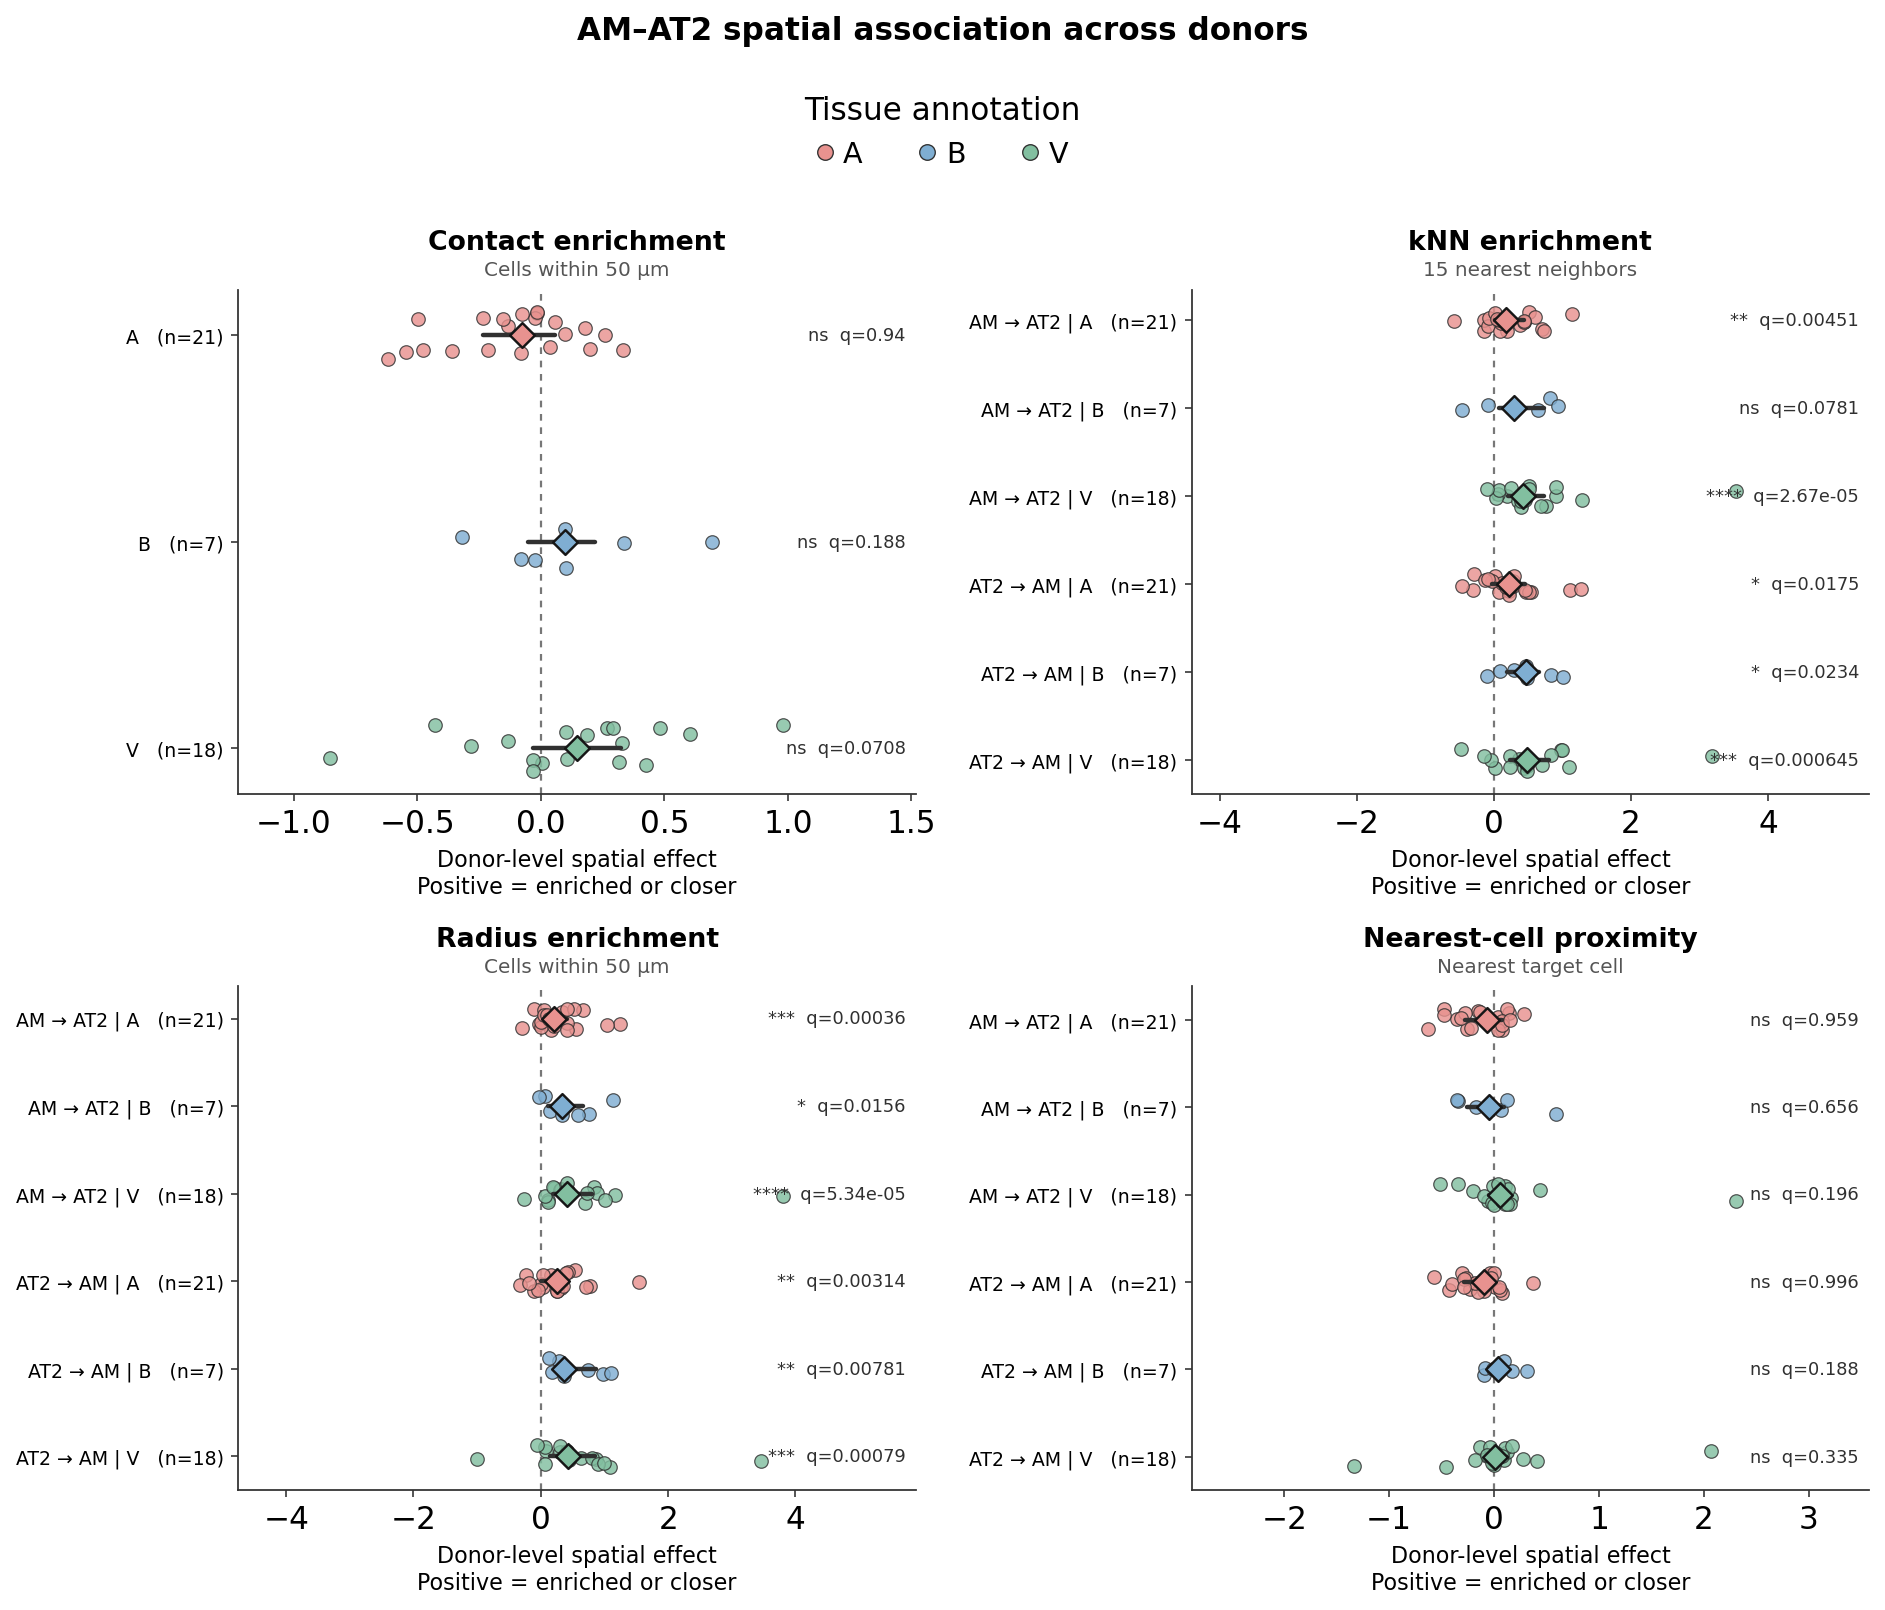

In [16]:
fig, axes, stage1B_primary_plot_data = (
    source.plot_stage1B_primary(
        donor_summary=stage1B_donor_summary,
        tissue_tests=stage1B_tissue_tests,
        tissue_order=("A", "B", "V"),
        save="Stage1B_AM_AT2_primary_results.pdf",
        dpi=300,
    )
)